### To execute this notebook, first install the used dependencies on your local environment or machine
Use the command: 
```
pip install -r requirements.txt
```

In [1]:
## Load the used libraries
import pandas as pd
from ydata_profiling import ProfileReport

In [2]:
## create a dataframe using the .csv dataset

df = pd.read_csv('dropout_dataset.csv', sep=';')
df.head()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


In [3]:
# Generate a brief overview of the dataset with pandas
df.describe(include='all')

,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
count,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,...,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Graduate
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2209
mean,1.178571,18.669078,1.727848,8856.642631,0.890823,4.577758,132.613314,1.873192,19.561935,22.275316,...,0.541817,6.232143,8.063291,4.435805,10.230206,0.150316,11.566139,1.228029,0.001969,NaN
std,0.605747,17.484682,1.313793,2063.566416,0.311897,10.216592,13.188332,6.914514,15.603186,15.343108,...,1.918546,2.195951,3.947951,3.014764,5.210808,0.753774,2.663850,1.382711,2.269935,NaN
min,1.000000,1.000000,0.000000,33.000000,0.000000,1.000000,95.000000,1.000000,1.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7.600000,-0.800000,-4.060000,NaN
25%,1.000000,1.000000,1.000000,9085.000000,1.000000,1.000000,125.000000,1.000000,2.000000,3.000000,...,0.000000,5.000000,6.000000,2.000000,10.750000,0.000000,9.400000,0.300000,-1.700000,NaN
50%,1.000000,17.000000,1.000000,9238.000000,1.000000,1.000000,133.100000,1.000000,19.000000,19.000000,...,0.000000,6.000000,8.000000,5.000000,12.200000,0.000000,11.100000,1.400000,0.320000,NaN
75%,1.000000,39.000000,2.000000,9556.000000,1.000000,1.000000,140.000000,1.000000,37.000000,37.000000,...,0.000000,7.000000,10.000000,6.000000,13.333333,0.000000,13.900000,2.600000,1.790000,NaN


In [4]:
# Remove the target column to allow a EDA report generation
# with the ydata_profiling package

EDA_dataset = df.drop(columns=['Target'])

### Use this cell below only to generate the EDA Report

In [5]:
# Generate a EDA report with the EDA dataset
# profile = ProfileReport(EDA_dataset, title="Profiling of the dataset")

## The generation of the report must be in a external file, embedding
## does not work
# profile.to_file("EDA_dropout_report.html")


Target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64


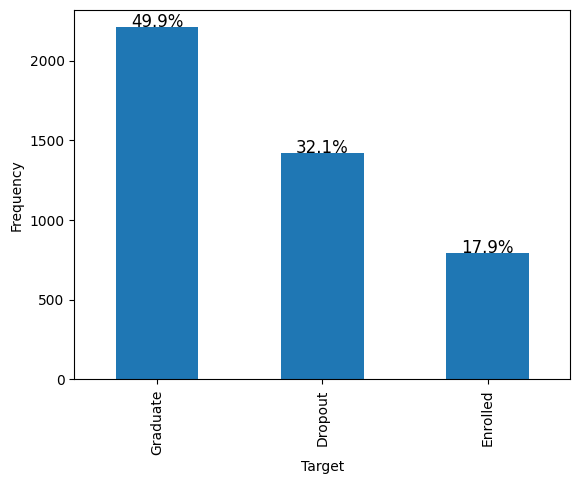

In [6]:
## A good thing to analyze is if our dataset is balanced or unbalanced, for that we can count the frequency of the unique values in the
## Target column

from matplotlib import pyplot as plt

print(df['Target'].value_counts())

fig, ax = plt.subplots()

# Count occurrences and calculate percentages
target_counts = df['Target'].value_counts()
total = target_counts.sum()
percentages = (target_counts / total) * 100

# Plot the bar chart
target_counts.plot(ax=ax, kind='bar', xlabel='Target', ylabel='Frequency')

# Annotate bars with percentages
for i, (count, pct) in enumerate(zip(target_counts, percentages)):
    ax.text(i, count + 1, f"{pct:.1f}%", ha='center', fontsize=12)

plt.show()

As per the output above, our data have a good amount of graduate and dropout data but the enrolled data (considered a Partial succes), the critical element for our analysis its unbalanced in relation to the rest of the dataset.

**Why enrolled is the most important** This is because on this part of the population, measures should be taken to avoid the unwanted outcome that is dropping out of college

In [7]:
#Remove trailing whitespace from the columns before doing the EDA treatments
for column in df.columns:
    df.rename(columns = {f'{column}':f'{column.rstrip().lstrip()}'})

#df.keys()

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance	                     4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Previous qualification (grade)                  4424 non-null   float64
 7   Nacionality                                     4424 non-null   int64  
 8   Mother's qualification                          4424 non-null   int64  
 9   Father's qualification                   

#### With the previous output we can see that there is no null value on the dataset

In [8]:
df_columns = df.columns.tolist()
print("----------------------List of columns with continuous data")
# 1. Continuous Data
# - Represents measurements and can take any value within a range (including decimals).
# - Example: Height (175.3 cm), Weight (68.5 kg), Temperature (36.7°C).
# - planned analysis methods -> ANOVA, Kruskal-Wallis, Boxplot, Violin Plot
df_continuous_columns = df[
    ['Previous qualification (grade)','Admission grade', 'Unemployment rate', 
    'Inflation rate','GDP', 'Curricular units 1st sem (grade)','Curricular units 2nd sem (grade)']
]
print(df_continuous_columns.columns.tolist())

print("----------------------List of columns with binary data")
# - planned analysis methods -> Chi-Square Test, Logistic Regression, Bar Charts
# problem with 'Daytime/evening attendance'
df_binary_columns = df[
    ['Daytime/evening attendance\t','Displaced', 'Educational special needs',
     'Debtor', 'Tuition fees up to date', 'Gender', 
     'Scholarship holder','International'
    ]
]
print(df_binary_columns.columns.tolist())

print("----------------------List of columns with discrete data")
# - planned analysis methods -> Chi-Square Test, Poisson Regression, Bar Charts/Histograms
df_discrete_columns = df[
    ['Age at enrollment', 'Curricular units 1st sem (credited)','Curricular units 1st sem (enrolled)',
     'Curricular units 1st sem (evaluations)','Curricular units 1st sem (approved)',
     'Curricular units 1st sem (without evaluations)', 'Curricular units 2nd sem (enrolled)',
     'Curricular units 2nd sem (evaluations)','Curricular units 2nd sem (approved)',
     'Curricular units 2nd sem (without evaluations)'
    ]
]
print(df_discrete_columns.columns.tolist())

print("----------------------List of columns with categorical data")
# - planned analysis methods -> Chi-Square Test, Cramér’s V, Cross-tabulation
df_categorical_columns = df[
    ['Application mode', 'Course', 'Previous qualification', 'Nacionality',
     'Target',"Father's occupation", "Mother's occupation"
    ]
]
print(df_categorical_columns.columns.tolist())

print("----------------------List of columns with ordinal data")
# 3. Ordinal Data (A mix of categorical and numerical)
# - Discrete values that have a meaningful order/ranking, but differences between values may not be equal.
# - Example: Satisfaction rating (1 = Bad, 2 = Okay, 3 = Good, 4 = Excellent), Grades (A, B, C, D).
# Check application order, mother and father qualification ordinality
# - planned analysis methods -> Chi-Square for Trend, Ordinal Logistic Regression, Spearman's Rank
df_ordinal_columns = df[
    ['Marital status',  'Application order', "Mother's qualification", 
     "Father's qualification"
    ]
]
print(df_ordinal_columns.columns.tolist())

----------------------List of columns with continuous data
['Previous qualification (grade)', 'Admission grade', 'Unemployment rate', 'Inflation rate', 'GDP', 'Curricular units 1st sem (grade)', 'Curricular units 2nd sem (grade)']
----------------------List of columns with binary data
['Daytime/evening attendance\t', 'Displaced', 'Educational special needs', 'Debtor', 'Tuition fees up to date', 'Gender', 'Scholarship holder', 'International']
----------------------List of columns with discrete data
['Age at enrollment', 'Curricular units 1st sem (credited)', 'Curricular units 1st sem (enrolled)', 'Curricular units 1st sem (evaluations)', 'Curricular units 1st sem (approved)', 'Curricular units 1st sem (without evaluations)', 'Curricular units 2nd sem (enrolled)', 'Curricular units 2nd sem (evaluations)', 'Curricular units 2nd sem (approved)', 'Curricular units 2nd sem (without evaluations)']
----------------------List of columns with categorical data
['Application mode', 'Course', 'Pre

#### To proceed with the dataset descriptive analysis, lets study further the correlation between the target feature and the different other features, this needs to be made because the EDA generated report only considers kendall's correlation and that is not appropriate for datatypes as ordinal, categorical and etc...

To check the correlation between the categorical and continuous data we can try to use ANOVA, but first we need to check if the data columns actually meet the conditions for this test

In [9]:
import pandas as pd
import numpy as np
from scipy.stats import shapiro

target_col = df['Target'];
continuous_features = df_continuous_columns
alpha = 0.05

print("\n### Normality Test (Shapiro-Wilk) ###")
print("H0 -> Sample presents normal distribution")
for continuous_column in continuous_features:
    print(f"\nFeature: {continuous_column}")
    column_to_check = continuous_features[[f'{continuous_column}']]
    stat, p = shapiro(column_to_check)
    print('Statistics=%.3f, p=%.3f' % (stat, p))
    if p > alpha:
        print('Sample looks Gaussian (fail to reject H0)')
    else:
        print('Sample does not look Gaussian (reject H0)')


### Normality Test (Shapiro-Wilk) ###
H0 -> Sample presents normal distribution

Feature: Previous qualification (grade)
Statistics=0.980, p=0.000
Sample does not look Gaussian (reject H0)

Feature: Admission grade
Statistics=0.980, p=0.000
Sample does not look Gaussian (reject H0)

Feature: Unemployment rate
Statistics=0.935, p=0.000
Sample does not look Gaussian (reject H0)

Feature: Inflation rate
Statistics=0.924, p=0.000
Sample does not look Gaussian (reject H0)

Feature: GDP
Statistics=0.912, p=0.000
Sample does not look Gaussian (reject H0)

Feature: Curricular units 1st sem (grade)
Statistics=0.685, p=0.000
Sample does not look Gaussian (reject H0)

Feature: Curricular units 2nd sem (grade)
Statistics=0.704, p=0.000
Sample does not look Gaussian (reject H0)


Since our continuous features failed on the normality test (all of them had pvalue < 0.05), we cannot proceed with ANOVA since the distribution is not normal. Now that we know that ANOVA is not possible, a recommended option is to use CRAMERS'v

**IT WOULD BE NICE TO PUT ON THE PAPER WHY THIS WAS CHOOSEN OVER OTHERS**

In [10]:
import numpy as np
import pandas as pd
from scipy.stats import chi2_contingency

def interpret_cramers_v(cramers_v, p_value):
    # Check significance
    if p_value < 0.05:
        significance = "statistically significant"
    else:
        significance = "not statistically significant"
    
    # Check strength of association
    if cramers_v < 0.1:
        association = "very weak"
    elif 0.1 <= cramers_v < 0.3:
        association = "weak"
    elif 0.3 <= cramers_v < 0.5:
        association = "moderate"
    elif 0.5 <= cramers_v < 0.7:
        association = "strong"
    else:
        association = "very strong"
    
    # Print interpretation
    print(f"The association is {association} and the result is {significance} (Cramér’s V: {cramers_v:.4f}, p-value: {p_value:.4f})")


continuous_features = df_continuous_columns


print("\n### Cramer's V test for correlation ###")
for continuous_column in continuous_features:
    print(f"\nFeature: {continuous_column}")
    # Bin the continuous column into 4 categories (quartiles, for example)
    df[f'Binned {continuous_column}'] = pd.qcut(df[continuous_column], q=4, labels=["Q1", "Q2", "Q3", "Q4"])
    
    # Create contingency table for Cramér's V calculation
    contingency_table = pd.crosstab(df[f'Binned {continuous_column}'], df['Target'])
    
    # Calculate Cramér's V
    chi2, p, dof, expected = chi2_contingency(contingency_table)
    n = df.shape[0]
    phi2 = chi2 / n
    r, k = contingency_table.shape
    cramer_v = np.sqrt(phi2 / min(r - 1, k - 1))
    
    print(f"Cramér’s V: {cramer_v:.4f}, p={p:.4f}")
    interpret_cramers_v(cramer_v,p)


### Cramer's V test for correlation ###

Feature: Previous qualification (grade)
Cramér’s V: 0.1236, p=0.0000
The association is weak and the result is statistically significant (Cramér’s V: 0.1236, p-value: 0.0000)

Feature: Admission grade
Cramér’s V: 0.0921, p=0.0000
The association is very weak and the result is statistically significant (Cramér’s V: 0.0921, p-value: 0.0000)

Feature: Unemployment rate
Cramér’s V: 0.0541, p=0.0002
The association is very weak and the result is statistically significant (Cramér’s V: 0.0541, p-value: 0.0002)

Feature: Inflation rate
Cramér’s V: 0.0487, p=0.0019
The association is very weak and the result is statistically significant (Cramér’s V: 0.0487, p-value: 0.0019)

Feature: GDP
Cramér’s V: 0.0478, p=0.0026
The association is very weak and the result is statistically significant (Cramér’s V: 0.0478, p-value: 0.0026)

Feature: Curricular units 1st sem (grade)
Cramér’s V: 0.3648, p=0.0000
The association is moderate and the result is statisticall

Now, to check the correlation between the binary columns and the target feature we can go straight to the Cramer's V test since it is the most recomended for this kind of analysis (binary x categorical nominal) 
**IT WILL BE NICE TO HAVE A EXPLANATION ON THE PAPER WHY THIS IS THE MOST APPROPRIATE COMPARISION FOR THAT**

**Statistically significant means that the data situation is unlikely to happen randomly, it is a big hint into a relation**

In [11]:


binary_columns = df_binary_columns

print("\n### Cramer's V test for correlation ###")
for binary_column in binary_columns:
    print(f"\nFeature: {binary_column}")
    
    # Create contingency table for Cramér's V calculation
    contingency_table = pd.crosstab(df[f'{binary_column}'], df['Target'])
    
    # Calculate Cramér's V
    chi2, p, dof, expected = chi2_contingency(contingency_table)
    n = df.shape[0]
    phi2 = chi2 / n
    r, k = contingency_table.shape
    cramer_v = np.sqrt(phi2 / min(r - 1, k - 1))
    
    print(f"Cramér’s V: {cramer_v:.4f}, p={p:.4f}")
    interpret_cramers_v(cramer_v,p)


### Cramer's V test for correlation ###

Feature: Daytime/evening attendance	
Cramér’s V: 0.0806, p=0.0000
The association is very weak and the result is statistically significant (Cramér’s V: 0.0806, p-value: 0.0000)

Feature: Displaced
Cramér’s V: 0.1143, p=0.0000
The association is weak and the result is statistically significant (Cramér’s V: 0.1143, p-value: 0.0000)

Feature: Educational special needs
Cramér’s V: 0.0120, p=0.7254
The association is very weak and the result is not statistically significant (Cramér’s V: 0.0120, p-value: 0.7254)

Feature: Debtor
Cramér’s V: 0.2421, p=0.0000
The association is weak and the result is statistically significant (Cramér’s V: 0.2421, p-value: 0.0000)

Feature: Tuition fees up to date
Cramér’s V: 0.4315, p=0.0000
The association is moderate and the result is statistically significant (Cramér’s V: 0.4315, p-value: 0.0000)

Feature: Gender
Cramér’s V: 0.2296, p=0.0000
The association is weak and the result is statistically significant (Cramér